In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSVs
business_df = pd.read_csv('../data/business.csv')
economy_df = pd.read_csv('../data/economy.csv')

# Label cabin class
business_df['class'] = 'Business'
economy_df['class'] = 'Economy'

# Merge into one dataset & drop exact duplicates
df = pd.concat([business_df, economy_df], ignore_index=True)
df = df.drop_duplicates()

print(f"Total rows: {len(df):,}")
df.head()

Total rows: 300,259


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612",Business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612",Business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220",Business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450",Business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690",Business


In [6]:
# 1. Clean price: remove commas like "25,612" -> 25612.0
df['price'] = df['price'].astype(str).str.replace(',', '').astype(float)

# 2. Parse time_taken ("02h 15m") into total minutes (135)
def parse_duration(val):
    val_str = str(val).strip()
    if 'h' in val_str:
        parts = val_str.split('h')
        hours = float(parts[0]) if parts[0] else 0.0
        min_part = parts[1].replace('m', '').strip()
        minutes = float(min_part) if min_part else 0.0
        return int(hours * 60 + minutes)
    return np.nan

df['duration_min'] = df['time_taken'].apply(parse_duration)

# 3. Extract day of week from date string
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['day_of_week'] = df['date'].dt.dayofweek

print("Missing values check:")
print(df.isnull().sum())

Missing values check:
date            0
airline         0
ch_code         0
num_code        0
dep_time        0
from            0
time_taken      0
stop            0
arr_time        0
to              0
price           0
class           0
duration_min    0
day_of_week     0
dtype: int64


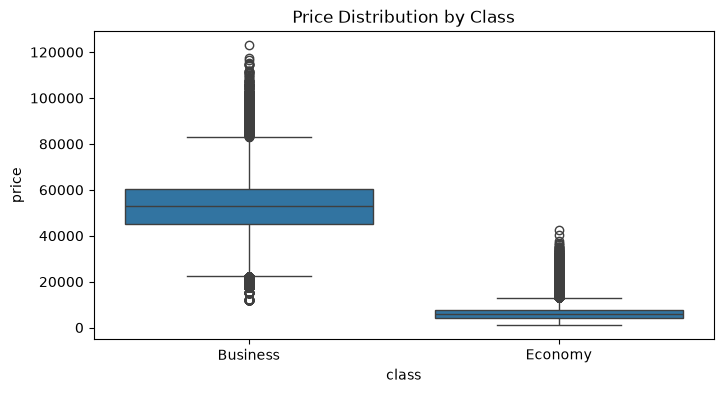

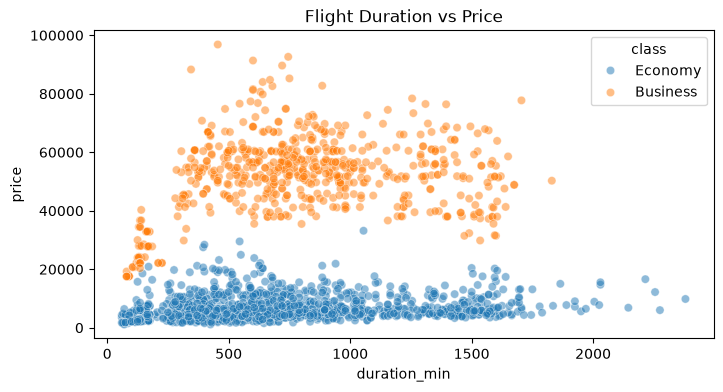

In [ ]:
# # Plot 1: Price difference between Business and Economy
# plt.figure(figsize=(8, 4))
# sns.boxplot(data=df, x='class', y='price')
# plt.title('Price Distribution by Class')
# plt.show()

# # Plot 2: Flight duration vs Price
# plt.figure(figsize=(8, 4))
# sns.scatterplot(data=df.sample(2000, random_state=42), x='duration_min', y='price', hue='class', alpha=0.5)
# plt.title('Flight Duration vs Price')
# plt.show()

In [8]:
# Select features to keep for modeling
features = ['airline', 'from', 'to', 'stop', 'class', 'duration_min', 'day_of_week']
X = df[features]
y = df['price']  # Target variable

# Convert categorical text into binary dummy variables (0/1)
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original features shape:", X.shape)
print("Encoded features shape (all numeric):", X_encoded.shape)
X_encoded.head()

Original features shape: (300259, 7)
Encoded features shape (all numeric): (300259, 59)


,duration_min,day_of_week,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,airline_Vistara,from_Chennai,...,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia RPR\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Raipur\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Ranchi\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Surat\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia VTZ\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Vishakhapatnam\n\t\t\t\t\t\t\t\t\t\t\t\t,stop_2+-stop,stop_non-stop,class_Economy
0,120,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,135,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1485,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1590,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,400,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
from sklearn.model_selection import train_test_split

# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")

Training set size: 240,207 samples
Test set size: 60,052 samples


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained successfully!")

# Model 2: Random Forest Regressor (using n_estimators=100 and n_jobs=-1 for faster execution)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

Linear Regression trained successfully!
Random Forest trained successfully!


In [11]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Make predictions on the test set
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calculate metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = root_mean_squared_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

# Calculate metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

# Display comparison summary
results_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [lr_mae, lr_rmse, lr_r2],
    'Random Forest': [rf_mae, rf_rmse, rf_r2]
})

results_df

,Metric,Linear Regression,Random Forest
0,MAE,4881.631980,2750.561134
1,RMSE,7039.359927,4254.754939
2,R2 Score,0.903570,0.964772
